# Chapter 45 — Radio Galaxies, AGN & the Radio Source Population

!!! info "Before you start"
    **Prerequisites:** Ch 43 (Synchrotron Radiation), Ch 44 (Free-free & HII Regions), Ch 7 (Why Interferometry) · **Maths Lab:** none · **~60 min** · **Intermediate–Advanced**

[Chapter 43](43_synchrotron_radiation.ipynb) gave us the physics engine: relativistic
electrons spiralling in magnetic fields produce synchrotron radiation — steep, polarised,
non-thermal.  Here we meet the most powerful *machines* that run that engine:
**radio galaxies and active galactic nuclei (AGN)**, each powered by accretion onto a
supermassive black hole, and each launching jets whose lobes can outshine the entire
host galaxy at metre wavelengths.

These sources are not just beautiful; they are cosmological probes.  Counting them — the
**log N–log S** technique — was the observation that broke steady-state cosmology in
1961 and revealed that the Universe evolves.  The same counting game, now pushed to
nano-Jansky depths with the VLA and MeerKAT, is still used to separate the
star-forming-galaxy population from the AGN and to constrain dark energy.

This chapter is Part IV real-data work: we query the **NVSS** (the NRAO VLA Sky Survey)
via VizieR to build an empirical log N–log S relation, and we bring in
`jansky.sourcecounts` for all the statistical machinery.

## Learning goals

By the end of this chapter you will be able to:

- **Distinguish** FR I (edge-darkened) from FR II (edge-brightened) radio galaxies by
  morphology and by their position relative to the FR I/II luminosity break
  ($\sim 10^{25}$ W Hz$^{-1}$ at 178 MHz).
- **Explain** the radio-loud AGN unified model: how orientation controls whether we see
  a quasar, a radio galaxy, or a blazar.
- **Derive** the static-Euclidean $N(>S) \propto S^{-3/2}$ slope from pure geometry and
  explain why the *observed* slope differs — the signature of cosmic evolution.
- **Use** `jansky.sourcecounts` to compute Euclidean integral/differential counts,
  Euclidean-normalised counts $S^{5/2}\,\mathrm{d}N/\mathrm{d}S$, and a power-law
  slope fit.
- **Apply** the toy $(1+z)^q$ evolution factor to show how positive evolution tilts the
  normalised counts.
- **Build** an empirical log N–log S curve from real NVSS catalogue data (or a
  physically motivated synthetic fallback) and **fit** the bright-end slope.
- **Interpret** the radio luminosity function $\Phi(L)$ — faint star-forming galaxies at
  the low end, rare powerful AGN at the high end.


## The history and the key papers

### Source counts as a cosmological test (1950s–1961)

When Martin Ryle's Cambridge group began counting radio sources in the late 1940s they
expected — as the steady-state model predicted — that the number of sources brighter
than a flux $S$ would follow the Euclidean law $N(>S) \propto S^{-3/2}$, modified
perhaps slightly but not dramatically by cosmology.  They did not find this.

> **Ryle, M. & Clarke, R. W.** (1961), "An Examination of the Steady-State Model in
> the Light of Some Recent Observations of Radio Sources,"
> *Monthly Notices of the Royal Astronomical Society* **122**, 349.
> [ADS](https://ui.adsabs.harvard.edu/abs/1961MNRAS.122..349R)

Ryle & Clarke analysed the 2C and 3C catalogues and showed that the *observed* counts
rise **more steeply** than $S^{-3/2}$ at bright flux: there were far more faint sources
than the steady-state model (or a non-evolving Friedmann model) could explain.  The
only consistent interpretation was that the **radio-source population was denser or more
luminous in the past** — evolution.  This observation struck a decisive blow against
steady-state cosmology and lent strong support to the Big Bang model.  Ryle received the
Nobel Prize in Physics in 1974 (shared with Antony Hewish) partly for this work
(see also Ch 7 on aperture synthesis — the instrument that made it possible).

### The FR I / FR II morphological split (1974)

Once high-resolution radio imaging (aperture synthesis — Ch 7, Ch 8) made it possible
to map the *structure* of radio galaxies, a remarkable discovery followed:

> **Fanaroff, B. L. & Riley, J. M.** (1974), "The Morphology of Extragalactic Radio
> Sources of High and Low Luminosity,"
> *Monthly Notices of the Royal Astronomical Society* **167**, 31P.
> [ADS](https://ui.adsabs.harvard.edu/abs/1974MNRAS.167P..31F)

Fanaroff & Riley divided 57 radio galaxies from the 3CR catalogue into two classes on
the basis of a single, simple morphological criterion — the **ratio of the distance
between the inner bright regions to the total source extent**:

- **FR I**: ratio < 0.5.  The *brightest* radio emission is near the **nucleus and inner
  jets** (edge-*darkened*); outer lobes fade away.  Lower luminosity (below the FR I/II
  break $P_{178} \sim 2\times10^{25}$ W Hz$^{-1}$).  Examples: M 87 (Virgo A), Centaurus A.
- **FR II**: ratio > 0.5.  The *brightest* emission is at the **outer extremities** —
  the **hotspots** where the jet terminates in the ambient medium (edge-*brightened*).
  Higher luminosity.  Example: Cygnus A.

The luminosity boundary between the two classes (the **FR I/II break**) is
$P_{178\,\mathrm{MHz}} \approx 2\times10^{25}$ W Hz$^{-1}$ (Fanaroff & Riley's original
value; they wrote it as W Hz$^{-1}$ sr$^{-1}$, whereas modern usage quotes W Hz$^{-1}$)
and separates jet-dominated (FR I) from lobe-dominated (FR II) morphologies.

### Radio–far-infrared correlation and normal galaxies (1992)

Not all radio sources are AGN-powered.  Galaxies with vigorous star formation emit
prodigious synchrotron radiation from electrons accelerated by supernova remnants
(Ch 43), and they follow the tight **radio–FIR correlation**:

> **Condon, J. J.** (1992), "Radio Emission from Normal Galaxies,"
> *Annual Review of Astronomy and Astrophysics* **30**, 575.
> [ADS](https://ui.adsabs.harvard.edu/abs/1992ARA%26A..30..575C)

Condon's review established the physical framework linking supernova rate, FIR
luminosity, and 1.4 GHz luminosity, and introduced the radio luminosity function that
we use in this chapter.  At faint flux densities ($S_{1.4} \lesssim 1$ mJy) the radio
source population is dominated by these star-forming galaxies, which outnumber AGN by
an order of magnitude.

### Modern source counts: de Zotti et al. (2010)

> **de Zotti, G., Massardi, M., Negrello, M., & Wall, J.** (2010), "Radio and
> Millimeter Continuum Surveys and their Astrophysical Implications,"
> *Astronomy & Astrophysics Review* **18**, 1.
> [ADS](https://ui.adsabs.harvard.edu/abs/2010A%26ARv..18....1D)

The radio catalogue used for the source counts in this chapter is the NRAO VLA Sky
Survey (NVSS):

> **Condon, J. J., Cotton, W. D., Greisen, E. W., et al.** (1998), "The NRAO VLA Sky
> Survey," *Astronomical Journal* **115**, 1693.
> [ADS](https://ui.adsabs.harvard.edu/abs/1998AJ....115.1693C)

de Zotti et al. compiled the best-available source counts across 0.1–857 GHz and
provided the standard modern picture: at 1.4 GHz the Euclidean-normalised differential
counts show a clear **bright-end excess** (positive evolution of the AGN population) and
a **faint-end upturn** (steeply rising star-forming galaxies below a few mJy).

### The textbook references

> **Condon, J. J. & Ransom, S. M.** (2016), *Essential Radio Astronomy* (ERA),
> Chapters 2 & 5.  Princeton University Press.
> Free online: [https://science.nrao.edu/opportunities/courses/era](https://science.nrao.edu/opportunities/courses/era)

> **Fanaroff & Riley** (1974) — FR morphology (above).


## The physics

### 1. FR I vs FR II morphology

The two morphological classes reflect fundamentally different **jet–medium interactions**.

An **FR I** jet decelerates while still within the inner few kiloparsecs of the host
galaxy, transferring momentum to the surrounding interstellar medium.  The flow becomes
*sub-relativistic* and turbulent; synchrotron emission fades steadily outward (spectral
aging + dilution).  The result is edge-**darkened**: brightest near the core.

An **FR II** jet remains relativistic to large distances, terminating in a strong
reverse shock — the **hotspot** — where the jet meets the external intergalactic
medium.  The hotspot is the site of *in situ* particle acceleration; the radio emission
is therefore brightest at the **outer edges** of the source: edge-**brightened**.

The **Fanaroff–Riley luminosity break** at 178 MHz is

$$
\boxed{P_{\rm FR\,I/II} \;\approx\; 2\times10^{25}\ \mathrm{W\,Hz^{-1}} \quad \text{at } 178\,\mathrm{MHz}}
$$

Sources below this are predominantly FR I; above it, FR II.  The break depends weakly
on host-galaxy optical luminosity (more luminous hosts can harbour higher-power FR Is),
and it is a *statistical* separator with real scatter: M 87, for instance, sits just
above the power break yet keeps its FR I morphology.  (Fanaroff & Riley's original value
was quoted as $2\times10^{25}$ W Hz$^{-1}$ sr$^{-1}$; modern usage absorbs the $4\pi$ into
the luminosity and quotes W Hz$^{-1}$.)

### 2. The radio-loud AGN unified model

All jetted AGN are believed to be intrinsically similar: a **supermassive black hole**
(SMBH) accreting material generates a relativistic, collimated **jet**.  Orientation
toward the observer controls which structure dominates:

| Viewing angle to jet | Observed class |
|---|---|
| $\sim 0^\circ$ (pole-on) | Blazar / BL Lac / flat-spectrum radio quasar |
| $\sim 30$–$60^\circ$ | Broad-line radio quasar |
| $\sim 60$–$90^\circ$ (edge-on) | Narrow-line radio galaxy |

The **jets** are visible in FR I as diffuse plumes and in FR II as compact, Doppler-
boosted features.  The **lobes** accumulate synchrotron-emitting plasma ejected over
the source lifetime ($10^7$–$10^8$ yr).

### 3. The static-Euclidean source count: $N(>S) \propto S^{-3/2}$

Consider a universe that is static, infinite, and uniformly filled with sources of
**identical** luminosity $L$.  A source at distance $r$ has flux

$$
S = \frac{L}{4\pi r^2}.
$$

The number of sources with $r < r_{\rm max}$ is $N \propto r_{\rm max}^3$.
Since $r_{\rm max} \propto S^{-1/2}$, it follows directly that

$$
\boxed{N(>S) \;\propto\; S^{-3/2}}
$$

and the differential count is

$$
\frac{{\rm d}N}{{\rm d}S} \;\propto\; S^{-5/2}.
$$

These are the **Euclidean** slopes.  Note that the derivation holds for any luminosity
function: you integrate each luminosity bin over its own $r_{\rm max}(L)$ and the
$-3/2$ slope is the same for every bin.  Hence the total count also has slope $-3/2$
regardless of $\Phi(L)$ — a universal prediction of a non-evolving, non-relativistic
universe.

### 4. Why observed counts deviate: cosmic evolution

In a real, expanding universe two effects alter the counts:

1. **Cosmological geometry**: volume elements at high redshift are not $4\pi r^2\,\mathrm{d}r$.
   At modest redshift the correction is modest, but at $z \sim 1$–$3$ it is significant.
2. **Source evolution**: the comoving space density (or luminosity) of radio AGN was
   **higher at earlier epochs**.  A toy model is a density-evolution factor

$$
\boxed{\Phi(L, z) \;=\; \Phi(L, 0)\,(1+z)^q, \qquad q \approx 3\text{–}4}
$$

applied out to $z \sim 2$ and declining beyond.  This positive evolution means there
were *more* powerful sources in the past, boosting the counts at **bright flux**
(which samples high-$z$ sources) above the Euclidean prediction.  At **faint flux**
the star-forming-galaxy population dominates; their much weaker evolution causes the
counts to flatten below a few mJy.

The **Euclidean-normalised** differential count

$$
S^{5/2}\,\frac{{\rm d}N}{{\rm d}S}
$$

is flat for a non-evolving Euclidean population.  Any departure from a horizontal line
— excess at bright $S$, upturn at faint $S$ — is a direct signature of evolution.

### 5. The radio luminosity function $\Phi(L)$

The **radio luminosity function** (RLF) is the space density of sources per unit
logarithmic luminosity interval, $\Phi(L) \equiv \mathrm{d}n/\mathrm{d}\log L$ [Mpc$^{-3}$].
A convenient empirical description is a **smoothly broken double power law** (Condon 1992):

$$
\Phi(L) \;=\; \frac{\Phi_\star}{(L/L_\star)^{\alpha} + (L/L_\star)^{\beta}},
$$

with $\Phi_\star \sim 10^{-6}$ Mpc$^{-3}$, $L_\star \sim 10^{22}$–$10^{24}$ W Hz$^{-1}$,
$\alpha \approx 0.7$ (faint-end slope, shallow — many star-forming galaxies), and
$\beta \approx 2.2$ (bright-end slope, steep — rare AGN).  The `jansky.sourcecounts`
module implements this as `radio_luminosity_function`.

### 6. Cygnus A: the archetypal FR II radio galaxy

**Cygnus A** (3C 405, $z = 0.056$) is the second-brightest radio source in the entire
sky (after the Sun) and the definitive FR II radio galaxy.  Key numbers:

| Property | Value |
|---|---|
| Redshift | $z = 0.056$ |
| 178 MHz flux density | $\sim 9660$ Jy (3CRR; Laing, Riley & Longair 1983) |
| Radio luminosity (total) | $\sim 10^{45.5}$ erg s$^{-1}$ |
| 178 MHz power | $P_{178} \approx 7 \times 10^{28}$ W Hz$^{-1}$ |
| Total source extent | $\sim 120$ kpc (two lobes + core) |
| Hotspot extent | $\sim 5$–$10$ kpc |
| Equipartition field (lobes) | $\sim 30$–$40\,\mu$G (Ch 43) |

At $P_{178} \approx 7\times10^{28}$ W Hz$^{-1}$, Cygnus A sits **more than three
orders of magnitude above** the FR I/II break ($2\times10^{25}$ W Hz$^{-1}$) — firmly
FR II.


In [1]:
import warnings
warnings.filterwarnings("ignore")  # suppress deprecation noise

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import astropy.units as u
import astropy.constants as const
from scipy.optimize import curve_fit

from jansky import sourcecounts, plotting
from jansky.plotting import show_image

plotting.use_jansky_style()

print("Environment ready.")
print(f"  Euclidean integral slope  : {sourcecounts.EUCLIDEAN_INTEGRAL_SLOPE}")
print(f"  Euclidean differential slope: {sourcecounts.EUCLIDEAN_DIFFERENTIAL_SLOPE}")


Environment ready.
  Euclidean integral slope  : -1.5
  Euclidean differential slope: -2.5


## Toy radio maps: FR I (edge-darkened) vs FR II (edge-brightened)

The figure below synthesises schematic 2-D radio-intensity maps for a canonical FR I
and FR II source using numpy only — no real image data are needed to illustrate the
morphological difference.

- **FR I (left):** the two jet lobes peak near the core and fade outward.  A Gaussian
  brightness profile with maximum at the jet base captures the edge-darkened character.
- **FR II (right):** the two lobes are nearly invisible; the dominant emission comes from
  compact **hotspots** at the outer extremities where the jet terminates in a shock.
  Between the hotspots, diffuse bridge emission connects back to the core.

The colour scale is `inferno` (the `jansky` course default for images); the core is
marked with a cross on both maps.


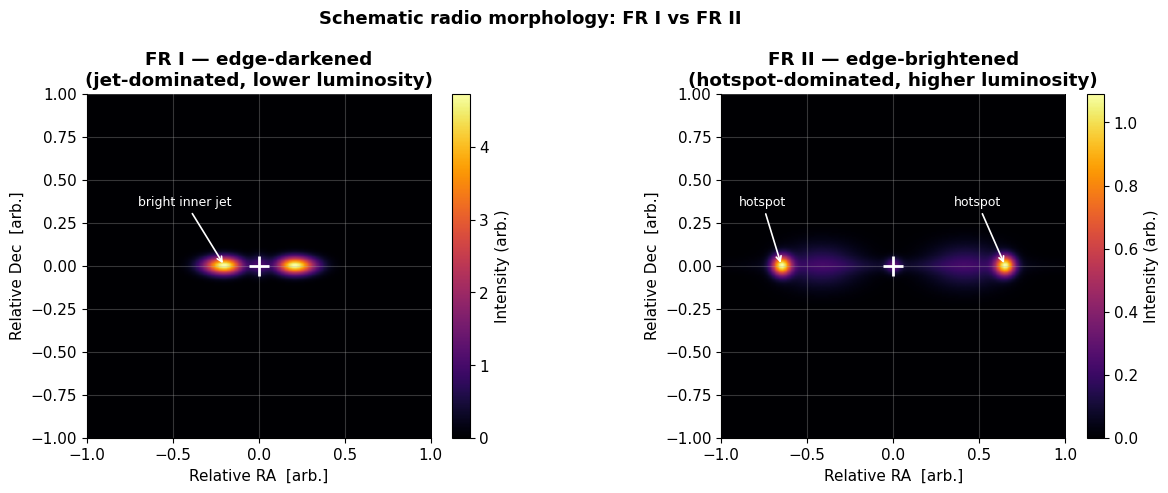

FR I  max brightness at  r ≈ 0.18 from core (inner jet).
FR II max brightness at  r ≈ 0.65 from core (outer hotspot).


In [2]:
# ---------------------------------------------------------------
# Toy FR I and FR II radio maps (pure numpy, no real data)
# ---------------------------------------------------------------

def gaussian_2d(x, y, x0, y0, sx, sy, amp):
    # 2-D Gaussian centred at (x0, y0) with widths (sx, sy)
    return amp * np.exp(-0.5 * ((x - x0)**2 / sx**2 + (y - y0)**2 / sy**2))

Npix = 256
xx, yy = np.meshgrid(np.linspace(-1, 1, Npix), np.linspace(-1, 1, Npix))
cx, cy = 0.0, 0.0   # core position

# ── FR I: edge-darkened ──────────────────────────────────────────────────────
# Two lobes: Gaussians centred at ±0.4 with moderate width, plus a bright core.
# The lobe peaks are BRIGHTER than the tips — brightness falls outward.
fri = np.zeros((Npix, Npix))

# Core
fri += gaussian_2d(xx, yy, cx, cy, 0.04, 0.04, 1.0)

# Left jet lobe: brightest near inner jet (~0.18 from core), fading outward
for r in np.linspace(0.15, 0.50, 30):
    amp = np.exp(-((r - 0.18) / 0.10)**2) * 0.6
    fri += gaussian_2d(xx, yy, -r, cy, 0.06, 0.035, amp)

# Right jet lobe (mirror)
for r in np.linspace(0.15, 0.50, 30):
    amp = np.exp(-((r - 0.18) / 0.10)**2) * 0.6
    fri += gaussian_2d(xx, yy, +r, cy, 0.06, 0.035, amp)

fri = np.clip(fri, 0, None)

# ── FR II: edge-brightened ───────────────────────────────────────────────────
# Bright hotspots at ±0.60, faint bridge + diffuse lobe, faint core.
frii = np.zeros((Npix, Npix))

# Faint core
frii += gaussian_2d(xx, yy, cx, cy, 0.03, 0.03, 0.25)

# Diffuse lobes (faint, wide)
frii += gaussian_2d(xx, yy, -0.42, cy, 0.16, 0.09, 0.18)
frii += gaussian_2d(xx, yy, +0.42, cy, 0.16, 0.09, 0.18)

# Bright hotspots at the outer extremities
frii += gaussian_2d(xx, yy, -0.65, cy, 0.04, 0.04, 1.00)
frii += gaussian_2d(xx, yy, +0.65, cy, 0.04, 0.04, 1.00)

# Faint bridge between lobes
frii += gaussian_2d(xx, yy, cx, cy, 0.60, 0.03, 0.06)

frii = np.clip(frii, 0, None)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vmin = 0.0

for ax, img, title in zip(
    axes,
    [fri, frii],
    ["FR I — edge-darkened\n(jet-dominated, lower luminosity)",
     "FR II — edge-brightened\n(hotspot-dominated, higher luminosity)"],
):
    im = ax.imshow(img, origin="lower", cmap="inferno",
                   vmin=vmin, vmax=img.max(),
                   extent=[-1, 1, -1, 1])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Intensity (arb.)")
    ax.set_xlabel("Relative RA  [arb.]")
    ax.set_ylabel("Relative Dec  [arb.]")
    ax.set_title(title)
    # Mark core
    ax.plot(cx, cy, "w+", ms=14, mew=2, zorder=5)

axes[0].annotate("bright inner jet", xy=(-0.20, 0.0),
                 xytext=(-0.70, 0.35), color="white", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="white", lw=1.2))
axes[1].annotate("hotspot", xy=(-0.65, 0.0),
                 xytext=(-0.90, 0.35), color="white", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="white", lw=1.2))
axes[1].annotate("hotspot", xy=(+0.65, 0.0),
                 xytext=(+0.35, 0.35), color="white", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="white", lw=1.2))

fig.suptitle("Schematic radio morphology: FR I vs FR II", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("FR I  max brightness at  r ≈ 0.18 from core (inner jet).")
print("FR II max brightness at  r ≈ 0.65 from core (outer hotspot).")


### Real FR I and FR II from VLASS

The maps above are schematic. Here are **real** images of the two morphologies at **VLASS**
resolution (2–4 GHz, 2.5″) — an **FR I** (M87 / Virgo A, jet-dominated, edge-darkened) and an
**FR II** (3C 98 — twin lobes and hotspots, edge-brightened) — pulled from the NRAO VLASS
quick-look survey with `astroquery.hips2fits`. Compare them with the toy profiles. (Browse any
source at the [NRAO VLASS portal](https://science.nrao.edu/vlass); the cell falls back to the
schematic profiles offline.)

Data source: live VLASS (NRAO quick-look HiPS)


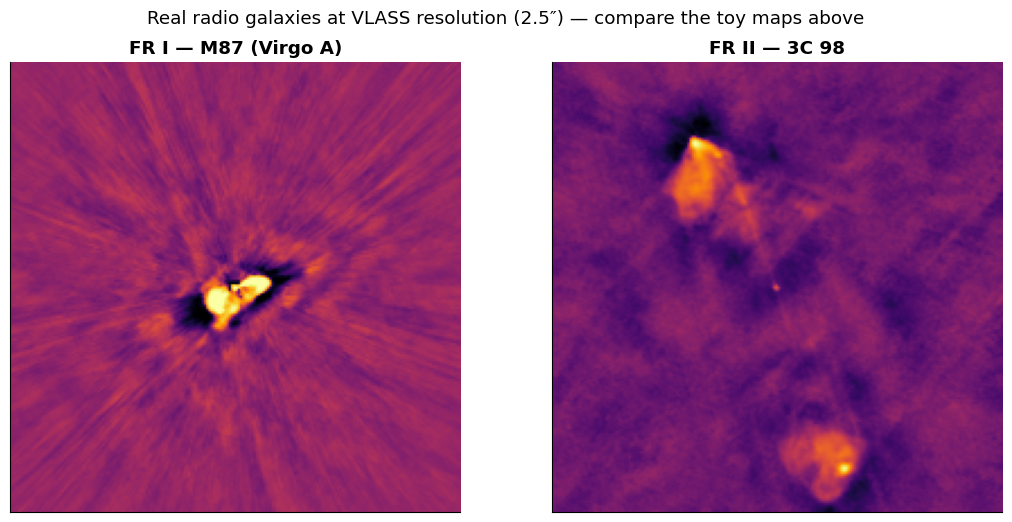

In [3]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

VLASS_HIPS = "NRAO/P/VLASS-Quicklook-MedianStack"
TARGETS = [("FR I — M87 (Virgo A)", "M87", 0.12),
           ("FR II — 3C 98", "3C 98", 0.10)]

# Well-known positions so the fetch needs no name-resolver call (offline failures then
# come from the HiPS service, not Sesame).
_VLASS_COORDS = {
    "M87": SkyCoord(187.70593, 12.39112, unit="deg"),
    "3C 98": SkyCoord(59.72682, 10.43411, unit="deg"),
}


def vlass_cutout(name, fov_deg, npix=200):
    from astroquery.hips2fits import hips2fits

    pos = _VLASS_COORDS.get(name) or SkyCoord.from_name(name)
    hdu = hips2fits.query(hips=VLASS_HIPS, width=npix, height=npix, fov=fov_deg * u.deg,
                          projection="TAN", ra=pos.ra, dec=pos.dec, format="fits")[0]
    data = hdu.data.astype(float)
    if not np.isfinite(data).any():
        raise ValueError(f"{name} falls in a VLASS quick-look gap")
    return np.nan_to_num(data)


def toy_fr(kind, npix=200):
    """The chapter's schematic FR profiles, reused as the offline fallback."""
    yy, xx = np.mgrid[0:npix, 0:npix].astype(float)
    cx = cy = npix / 2.0
    if kind == "I":  # edge-darkened: bright core + two fading inner lobes
        img = np.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * (0.06 * npix) ** 2)))
        for s in (-1, 1):
            lx = cx + s * 0.18 * npix
            img += 0.5 * np.exp(-(((xx - lx) ** 2 + (yy - cy) ** 2) / (2 * (0.13 * npix) ** 2)))
        return img
    img = np.zeros((npix, npix))  # edge-brightened: twin hotspots + inner lobes
    for s in (-1, 1):
        img += np.exp(-(((xx - (cx + s * 0.34 * npix)) ** 2 + (yy - cy) ** 2) / (2 * (0.05 * npix) ** 2)))
        img += 0.35 * np.exp(-(((xx - (cx + s * 0.20 * npix)) ** 2 + (yy - cy) ** 2) / (2 * (0.10 * npix) ** 2)))
    return img


try:
    maps = [vlass_cutout(name, fov) for _, name, fov in TARGETS]
    source = "live VLASS (NRAO quick-look HiPS)"
except Exception as exc:
    print(f"VLASS unavailable ({type(exc).__name__}: {exc}); using the schematic FR profiles.")
    maps = [toy_fr("I"), toy_fr("II")]
    source = "offline fallback (schematic FR profiles)"
print(f"Data source: {source}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.3))
for ax, (title, *_), m in zip(axes, TARGETS, maps):
    scale = np.nanpercentile(m, 99.5) or 1.0
    ax.imshow(np.arcsinh(m / scale * 6.0), origin="lower", cmap="inferno")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Real radio galaxies at VLASS resolution (2.5″) — compare the toy maps above")
fig.tight_layout()
plt.show()

### Figure 2 — The radio luminosity function $\Phi(L)$

The double-power-law luminosity function encodes the two populations that dominate the
radio sky at 1.4 GHz.  The faint (low-$L$) end, with slope $\alpha \approx 0.7$, is
dominated by **star-forming galaxies** — their synchrotron emission is powered by
supernova remnants and scales with the star-formation rate (Condon 1992).
The bright (high-$L$) end, with the steeper slope $\beta \approx 2.2$, is dominated by
**radio-loud AGN** — rare, but their extreme luminosities mean they account for most
of the radio sky's bright sources.

The break luminosity $L_\star \approx 10^{23}$ W Hz$^{-1}$ sits near the boundary
between the two populations at $z \approx 0$.  The FR I/II luminosity break at
$P_{178} \approx 10^{25}$ W Hz$^{-1}$ is marked for context.


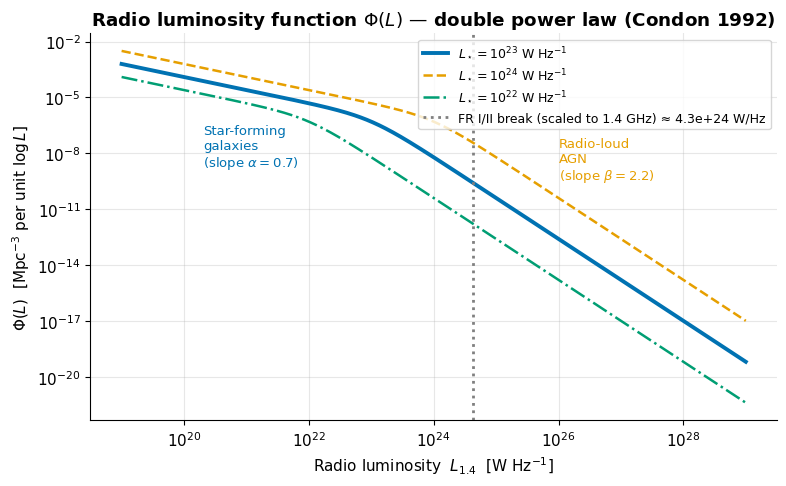

Phi at the break L_star (= 1e23 W/Hz) : 5.000e-07  Mpc^-3 per unit log L
FR I/II break at 1.4 GHz   : 4.26e+24  W/Hz
  (scaled from 10^25 W/Hz at 178 MHz with alpha=-0.75)


In [4]:
L_arr = np.logspace(19, 29, 500)   # W/Hz  (1.4 GHz)

# Parameters (Condon 1992 spirit): phi_star=1e-6, l_star=1e23, alpha=0.7, beta=2.2
# (the composite-population break near 1.4 GHz; pass l_star explicitly).
phi_default = sourcecounts.radio_luminosity_function(L_arr, l_star=1e23)

# Show sensitivity to the break luminosity
phi_hi = sourcecounts.radio_luminosity_function(L_arr, l_star=1e24)
phi_lo = sourcecounts.radio_luminosity_function(L_arr, l_star=1e22)

fig, ax = plt.subplots()

ax.loglog(L_arr, phi_default, lw=2.8, label=r"$L_\star = 10^{23}$ W Hz$^{-1}$")
ax.loglog(L_arr, phi_hi,      lw=1.8, ls="--",
          label=r"$L_\star = 10^{24}$ W Hz$^{-1}$")
ax.loglog(L_arr, phi_lo,      lw=1.8, ls="-.",
          label=r"$L_\star = 10^{22}$ W Hz$^{-1}$")

# Mark the FR I/II break (at 178 MHz; scale to 1.4 GHz assuming alpha=-0.75)
alpha_scale = -0.75
P_178_break = 2e25   # W/Hz at 178 MHz (Fanaroff & Riley 1974)
P_1400_break = P_178_break * (1400 / 178) ** alpha_scale
ax.axvline(P_1400_break, color="0.5", ls=":", lw=2,
           label=f"FR I/II break (scaled to 1.4 GHz) ≈ {P_1400_break:.1e} W/Hz")

# Label the two populations
ax.text(2e20, 2e-8, "Star-forming\ngalaxies\n" + r"(slope $\alpha=0.7$)",
        fontsize=9.5, color="#0072B2", va="center")
ax.text(1e26, 4e-9, "Radio-loud\nAGN\n" + r"(slope $\beta=2.2$)",
        fontsize=9.5, color="#E69F00", va="center")

ax.set_xlabel(r"Radio luminosity  $L_{1.4}$  [W Hz$^{-1}$]")
ax.set_ylabel(r"$\Phi(L)$  [Mpc$^{-3}$ per unit $\log L$]")
ax.set_title(r"Radio luminosity function $\Phi(L)$ — double power law (Condon 1992)")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

L_star_used = 1e23
phi_at_break = sourcecounts.radio_luminosity_function(L_star_used, l_star=L_star_used)
print(f"Phi at the break L_star (= 1e23 W/Hz) : {phi_at_break:.3e}  Mpc^-3 per unit log L")
print(f"FR I/II break at 1.4 GHz   : {P_1400_break:.2e}  W/Hz")
print(f"  (scaled from 10^25 W/Hz at 178 MHz with alpha={alpha_scale})")


### Figure 3 — Static-Euclidean and evolved log N–log S counts

The left panel shows the integral count $N(>S)$ on log–log axes.  A non-evolving
Euclidean population (slope exactly $-3/2$) is shown alongside two evolved models using
the toy $(1+z)^q$ factor from `sourcecounts.evolution_factor`.  The right panel shows
the **Euclidean-normalised** differential count $S^{5/2}\,\mathrm{d}N/\mathrm{d}S$ —
the modern standard presentation.  A purely Euclidean population produces a
**horizontal line**.  Positive evolution ($q > 0$) introduces a **bright-end excess**
(the curve rises toward high $S$), exactly the signature seen in the real counts by
Ryle & Clarke (1961).


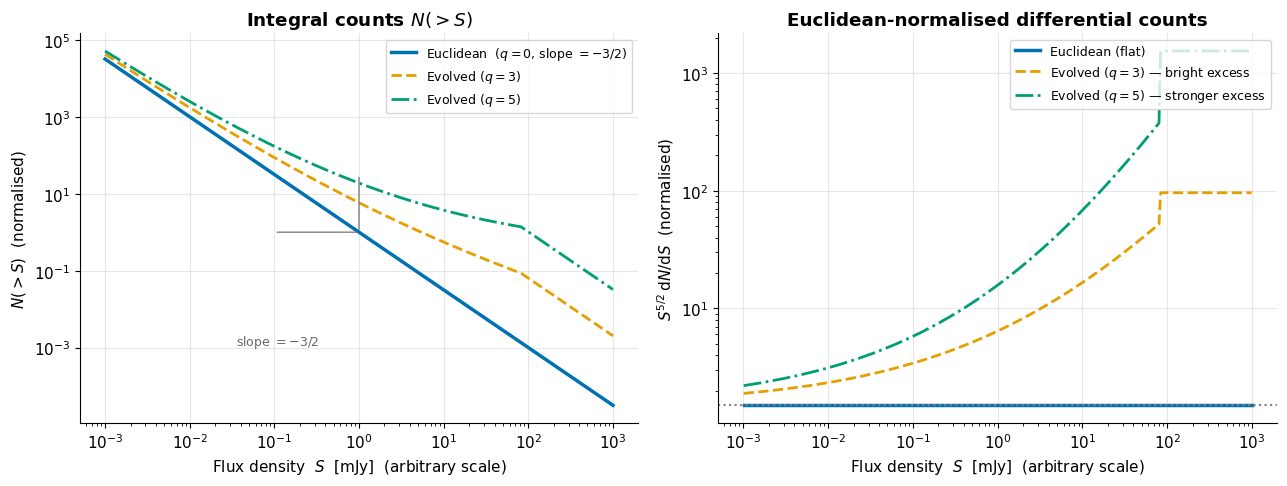

Euclidean integral-count slope : -1.500  (expected -1.500)
Evolved (q=3): bright-end normalised counts exceed the flat Euclidean
  line by ~64x -- the departure from the static prediction that
  Ryle & Clarke (1961) used to reject steady-state cosmology.


In [5]:
S_arr = np.logspace(-3, 3, 600)   # mJy (illustrative)

# --- Euclidean integral counts ---
N_euc = sourcecounts.euclidean_integral_counts(S_arr, n_ref=1.0, s_ref=1.0)

# --- Evolved integral counts: toy analytic model ---
# For illustration we apply a smooth evolution boost to the Euclidean normalisation.
# A flux-limited sample sees brighter sources out to higher redshift (Malmquist), so we
# let the effective <z> grow with S and apply a (1+z)^q boost. This is intentionally a
# PEDAGOGICAL toy, not a cosmological model.
def evolved_integral(S, q, s_ref=1.0, n_ref=1.0):
    # Toy evolved integral count: Euclidean base * a luminosity-dependent evolution boost.
    N_base = sourcecounts.euclidean_integral_counts(S, n_ref=n_ref, s_ref=s_ref)
    # Brighter sources probe higher z, so the effective <z> grows with S.
    z_eff = 0.8 * (np.asarray(S) / s_ref)**0.3   # grows toward bright S
    boost = sourcecounts.evolution_factor(np.clip(z_eff, 0, 3.0), q=q)
    return N_base * boost

N_evo3 = evolved_integral(S_arr, q=3.0)
N_evo5 = evolved_integral(S_arr, q=5.0)

# --- Differential counts ---
dS = np.diff(S_arr)
S_mid = 0.5 * (S_arr[:-1] + S_arr[1:])

dN_euc_dS = sourcecounts.euclidean_differential_counts(S_mid, n_ref=1.5, s_ref=1.0)

# Evolved differential from N_evo (numerical derivative)
dN_evo3_dS = -np.diff(N_evo3) / dS
dN_evo5_dS = -np.diff(N_evo5) / dS

# --- Euclidean-normalised ---
en_euc  = sourcecounts.euclidean_normalised_counts(S_mid, dN_euc_dS)
en_evo3 = sourcecounts.euclidean_normalised_counts(S_mid, np.abs(dN_evo3_dS))
en_evo5 = sourcecounts.euclidean_normalised_counts(S_mid, np.abs(dN_evo5_dS))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: integral counts
ax = axes[0]
ax.loglog(S_arr, N_euc,  lw=2.5, label="Euclidean  ($q=0$, slope $= -3/2$)")
ax.loglog(S_arr, N_evo3, lw=2.0, ls="--", label="Evolved ($q=3$)")
ax.loglog(S_arr, N_evo5, lw=2.0, ls="-.", label="Evolved ($q=5$)")
ax.set_xlabel("Flux density  $S$  [mJy]  (arbitrary scale)")
ax.set_ylabel("$N(>S)$  (normalised)")
ax.set_title(r"Integral counts $N(>S)$")
ax.legend(fontsize=9)

# Reference slope triangle
s_lo, s_hi = 0.1, 1.0
n_lo = sourcecounts.euclidean_integral_counts(s_lo)
n_hi = sourcecounts.euclidean_integral_counts(s_hi)
ax.annotate("", xy=(s_hi, n_hi), xytext=(s_lo, n_hi),
            arrowprops=dict(arrowstyle="-", color="0.5", lw=1))
ax.annotate("", xy=(s_hi, n_hi), xytext=(s_hi, n_lo),
            arrowprops=dict(arrowstyle="-", color="0.5", lw=1))
ax.text(0.28, 0.20, r"slope $= -3/2$", fontsize=9, color="0.4", transform=ax.transAxes)

# Right: Euclidean-normalised differential counts
ax2 = axes[1]
ax2.loglog(S_mid, en_euc,  lw=2.5, label="Euclidean (flat)")
ax2.loglog(S_mid, en_evo3, lw=2.0, ls="--", label="Evolved ($q=3$) — bright excess")
ax2.loglog(S_mid, en_evo5, lw=2.0, ls="-.", label="Evolved ($q=5$) — stronger excess")
ax2.set_xlabel("Flux density  $S$  [mJy]  (arbitrary scale)")
ax2.set_ylabel(r"$S^{5/2}\,{\rm d}N/{\rm d}S$  (normalised)")
ax2.set_title(r"Euclidean-normalised differential counts")
ax2.legend(fontsize=9, loc="upper right")
ax2.axhline(en_euc.mean(), color="0.5", ls=":", lw=1.5, label="flat (Euclidean)")

fig.tight_layout()
plt.show()

# The non-evolving population recovers the exact Euclidean slope; the evolved models
# lift the counts ABOVE the static prediction, seen as a bright-end excess in the
# Euclidean-normalised counts (right panel).
slope_euc = sourcecounts.count_slope(S_arr, N_euc)
bright = S_mid > 10
excess_q3 = np.median(en_evo3[bright]) / en_euc.mean()
print(f"Euclidean integral-count slope : {slope_euc:.3f}  (expected -1.500)")
print(f"Evolved (q=3): bright-end normalised counts exceed the flat Euclidean")
print(f"  line by ~{excess_q3:.0f}x -- the departure from the static prediction that")
print(f"  Ryle & Clarke (1961) used to reject steady-state cosmology.")


## Real data: log N–log S from the NVSS catalogue

The **NRAO VLA Sky Survey** (NVSS; Condon et al. 1998) covers the entire sky north of
$\delta = -40°$ at 1.4 GHz with an angular resolution of 45 arcsec and a completeness
limit of $\sim 2.5$ mJy.  It contains nearly **2 million** entries and is the standard
reference catalogue for extragalactic 1.4 GHz sources.

We perform a **cone-search** of the NVSS through VizieR (catalog "VIII/65") around a
test field (RA = 10h, Dec = +30°, radius 4 deg), retrieve flux densities in mJy, build
an empirical integral log N–log S using `sourcecounts.integral_counts`, and fit the
bright-end slope with `sourcecounts.count_slope`.

**Offline fallback:** if the VizieR query fails (no network, timeout, or any exception),
we simulate a physically motivated catalogue by drawing from a Pareto distribution
($P(S > x) = (x/S_{\rm min})^{-3/2}$, the exact Euclidean distribution) with a
faint-end rollover, and proceed identically.  The notebook prints which path was taken.


In [6]:
# ------------------------------------------------------------------
# NVSS cone search via astroquery/VizieR — with offline fallback
# ------------------------------------------------------------------
FIELD_RA  = "10h00m00s"
FIELD_DEC = "+30d00m00s"
CONE_DEG  = 4.0       # degrees
S_MIN_MJY = 3.0       # mJy completeness floor

_data_source = "OFFLINE FALLBACK (simulated Euclidean + rollover)"
nvss_flux_mjy = None

try:
    import astropy.coordinates as coord
    from astroquery.vizier import Vizier

    v = Vizier(columns=["S1.4"], row_limit=5000, timeout=30)
    center = coord.SkyCoord(FIELD_RA, FIELD_DEC, frame="icrs")
    result = v.query_region(center, radius=CONE_DEG * u.deg, catalog="VIII/65")

    if result and len(result) > 0:
        tbl = result[0]
        col = None
        for possible in ["S1.4", "S_1.4", "Sp", "S"]:
            if possible in tbl.colnames:
                col = possible
                break
        if col is not None:
            raw = tbl[col].data
            raw = np.asarray(raw, dtype=float)
            raw = raw[np.isfinite(raw) & (raw > S_MIN_MJY)]
            if len(raw) > 20:
                nvss_flux_mjy = raw
                _data_source = f"LIVE NVSS (VizieR VIII/65) — {len(nvss_flux_mjy)} sources"
            else:
                _data_source = "OFFLINE FALLBACK (too few NVSS sources returned)"
        else:
            _data_source = "OFFLINE FALLBACK (column not found in VizieR result)"
    else:
        _data_source = "OFFLINE FALLBACK (empty VizieR result)"

except Exception as _exc:
    _data_source = f"OFFLINE FALLBACK ({type(_exc).__name__})"

# --- Offline fallback: Pareto (Euclidean) + faint-end rollover ---------------
if nvss_flux_mjy is None:
    rng = np.random.default_rng(42)
    N_sim = 1500
    # Pareto: S = S_min * U^(-1/1.5) where U ~ Uniform(0,1)
    U = rng.uniform(0, 1, N_sim * 5)
    S_pareto = S_MIN_MJY * U ** (-1.0 / 1.5)
    # Impose a bright-end cutoff consistent with a ~4 deg cone (no source > 5 Jy)
    S_pareto = S_pareto[S_pareto < 5000.0]
    # Faint-end rollover: keep each source with prob proportional to
    # detection efficiency: eff = 1 - exp(-(S/S_roll)^2), S_roll = 5 mJy
    S_roll = 5.0
    eff = 1.0 - np.exp(-(S_pareto / S_roll)**2)
    keep = rng.uniform(0, 1, len(S_pareto)) < eff
    nvss_flux_mjy = S_pareto[keep][:N_sim]

print(f"Data source : {_data_source}")
print(f"N sources   : {len(nvss_flux_mjy)}")
print(f"Flux range  : {nvss_flux_mjy.min():.2f} – {nvss_flux_mjy.max():.2f} mJy")


Data source : LIVE NVSS (VizieR VIII/65) — 2148 sources
N sources   : 2148
Flux range  : 3.10 – 3411.80 mJy


### Figure 4 — Empirical log N–log S from the NVSS field (or offline simulation)

We build the integral count $N(>S)$ from the flux list using
`sourcecounts.integral_counts`, which sorts the fluxes and returns the running count.
We then fit the **bright-end slope** (sources brighter than 10 mJy where the sample is
complete) with `sourcecounts.count_slope` and compare to the Euclidean expectation
of $-1.5$.


Bright-end log N – log S slope  (S > 10.0 mJy) : -1.049
Full-range slope                (S > 3.0 mJy)   : -0.916
Euclidean expectation                                   : -1.500

Deviation from Euclidean (bright end): +0.451


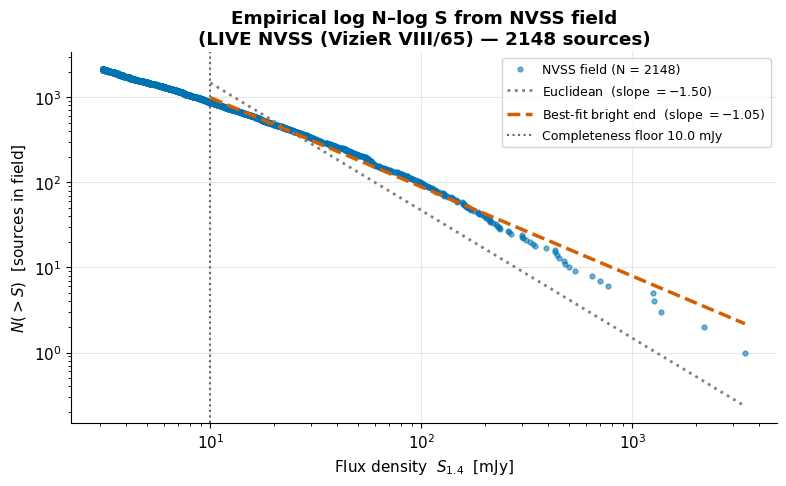

In [7]:
# ------------------------------------------------------------------
# Build empirical integral counts and fit the slope
# ------------------------------------------------------------------

# Integral counts: sorted descending flux + cumulative rank
S_sorted, N_cumul = sourcecounts.integral_counts(nvss_flux_mjy)

# Normalise to counts per square degree (field area ~ pi*(CONE_DEG/2)^2 is
# not known for the fallback; we use per-source normalisation for display)
area_sqdeg = np.pi * (CONE_DEG / 2.0) ** 2   # approx

# Fit bright-end slope (S > 10 mJy) — well above completeness limit
S_BRIGHT_FLOOR = 10.0   # mJy
mask_bright = S_sorted > S_BRIGHT_FLOOR
slope_bright = sourcecounts.count_slope(S_sorted[mask_bright], N_cumul[mask_bright])

# Also fit over the full range S > S_MIN_MJY for comparison
slope_full = sourcecounts.count_slope(S_sorted, N_cumul)

print(f"Bright-end log N – log S slope  (S > {S_BRIGHT_FLOOR} mJy) : {slope_bright:.3f}")
print(f"Full-range slope                (S > {S_MIN_MJY} mJy)   : {slope_full:.3f}")
print(f"Euclidean expectation                                   : -1.500")
print()
print(f"Deviation from Euclidean (bright end): {slope_bright - (-1.5):+.3f}")

# Euclidean reference line anchored at the median bright-end count
S_ref_anchor = np.percentile(S_sorted[mask_bright], 50)
N_ref_anchor = N_cumul[mask_bright][np.searchsorted(-S_sorted[mask_bright],
                                                     -S_ref_anchor)]
S_euc_line = np.logspace(np.log10(S_BRIGHT_FLOOR), np.log10(S_sorted.max()), 200)
N_euc_line = N_ref_anchor * (S_euc_line / S_ref_anchor) ** (-1.5)

# Best-fit line on bright sources
pfit = np.polyfit(np.log10(S_sorted[mask_bright]), np.log10(N_cumul[mask_bright]), 1)
N_fit_line = 10.0 ** np.polyval(pfit, np.log10(S_euc_line))

fig, ax = plt.subplots()
ax.loglog(S_sorted, N_cumul, "o", ms=3.5, alpha=0.55, color="#0072B2",
          label=f"NVSS field (N = {len(nvss_flux_mjy)})")
ax.loglog(S_euc_line, N_euc_line, lw=2.0, ls=":", color="0.5",
          label="Euclidean  (slope $= -1.50$)")
ax.loglog(S_euc_line, N_fit_line, lw=2.5, ls="--", color="#D55E00",
          label=f"Best-fit bright end  (slope $= {slope_bright:.2f}$)")
ax.axvline(S_BRIGHT_FLOOR, color="0.4", ls=":", lw=1.5,
           label=f"Completeness floor {S_BRIGHT_FLOOR} mJy")

ax.set_xlabel(r"Flux density  $S_{1.4}$  [mJy]")
ax.set_ylabel(r"$N(>S)$  [sources in field]")
ax.set_title(f"Empirical log N–log S from NVSS field\n({_data_source})")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


### Figure 5 — Euclidean-normalised differential counts $S^{5/2}\,\mathrm{d}N/\mathrm{d}S$

Multiplying the differential count by $S^{5/2}$ removes the steep Euclidean slope and
reveals the deviations that encode evolution.  We compute the differential counts in
logarithmically-spaced flux bins using `sourcecounts.differential_counts`, then
Euclidean-normalise with `sourcecounts.euclidean_normalised_counts`.  Poisson error bars
($\sqrt{N_{\rm bin}}$) are shown.  The horizontal dashed line marks a purely Euclidean
(non-evolving) population; points above it indicate positive evolution.


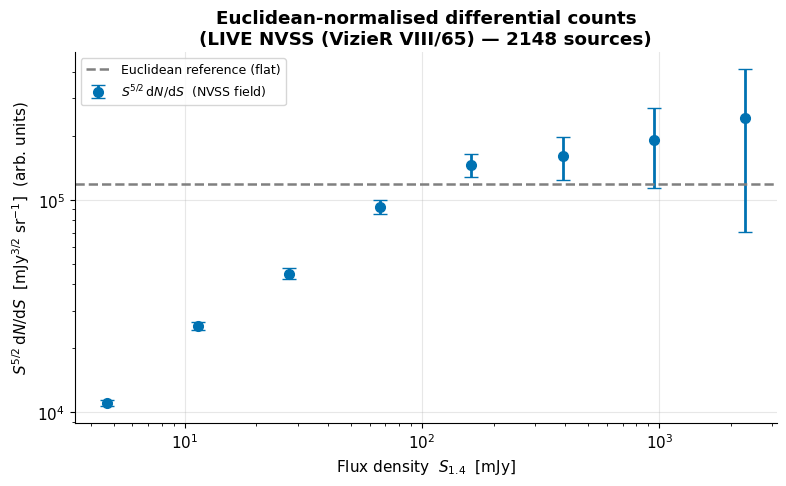

Bin summary (bins with ≥ 2 sources):
      S_centre [mJy]         dN/dS     S^2.5 dN/dS   N_bin
                4.67      234.2257      11046.5600    1001 *
               11.33       59.1602      25538.8083     613 *
               27.46       11.3842      44983.5125     286 *
               66.58        2.5611      92631.5873     156 *
              161.42        0.4401     145711.9066      65 *
              391.38        0.0531     160798.6736      19 *
              948.91        0.0069     191702.2844       6 *
             2300.68        0.0010     241242.1610       2 *


In [8]:
# ------------------------------------------------------------------
# Euclidean-normalised differential counts
# ------------------------------------------------------------------

# Flux bins: logarithmically spaced, 6 bins from S_MIN to max
bins = np.geomspace(S_MIN_MJY, nvss_flux_mjy.max() * 1.05, 9)
centres, dn_ds, dn_ds_err = sourcecounts.differential_counts(nvss_flux_mjy, bins)

# Euclidean-normalise: S^2.5 * dN/dS
en_data  = sourcecounts.euclidean_normalised_counts(centres, dn_ds)
en_err   = sourcecounts.euclidean_normalised_counts(centres, dn_ds_err)

# Only plot bins with at least 2 sources (avoid shot-noise-dominated single-source bins)
min_counts_per_bin = 2
hist_counts, _ = np.histogram(nvss_flux_mjy, bins=bins)
good = hist_counts >= min_counts_per_bin

# Euclidean reference level: use median of good bins
if good.sum() > 0:
    ref_level = np.median(en_data[good])
else:
    ref_level = np.median(en_data)

fig, ax = plt.subplots()
ax.errorbar(centres[good], en_data[good], yerr=en_err[good],
            fmt="o", ms=7, capsize=5, lw=2, color="#0072B2",
            label=r"$S^{5/2}\,{\rm d}N/{\rm d}S$  (NVSS field)")
ax.axhline(ref_level, color="0.5", ls="--", lw=1.8,
           label="Euclidean reference (flat)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Flux density  $S_{1.4}$  [mJy]")
ax.set_ylabel(r"$S^{5/2}\,{\rm d}N/{\rm d}S$  [mJy$^{3/2}$ sr$^{-1}$]  (arb. units)")
ax.set_title(r"Euclidean-normalised differential counts" + "\n" +
             f"({_data_source})")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print("Bin summary (bins with ≥ 2 sources):")
print(f"  {'S_centre [mJy]':>18}  {'dN/dS':>12}  {'S^2.5 dN/dS':>14}  {'N_bin':>6}")
for i, (s, dn, en, nc) in enumerate(zip(centres, dn_ds, en_data, hist_counts)):
    flag = " *" if nc >= min_counts_per_bin else ""
    print(f"  {s:>18.2f}  {dn:>12.4f}  {en:>14.4f}  {nc:>6d}{flag}")


### Figure 6 — FR I/II luminosity classification: where do famous sources fall?

The FR I/II morphological split correlates with radio luminosity at 178 MHz.
Sources below the break $P_{\rm break} \approx 10^{25}$ W Hz$^{-1}$ are predominantly
FR I (edge-darkened, jet-dominated); above it, FR II (edge-brightened, hotspot-dominated).
Here we place several well-known radio galaxies on the luminosity axis and compare to
the break, using redshifts and 178 MHz flux densities from published catalogues.


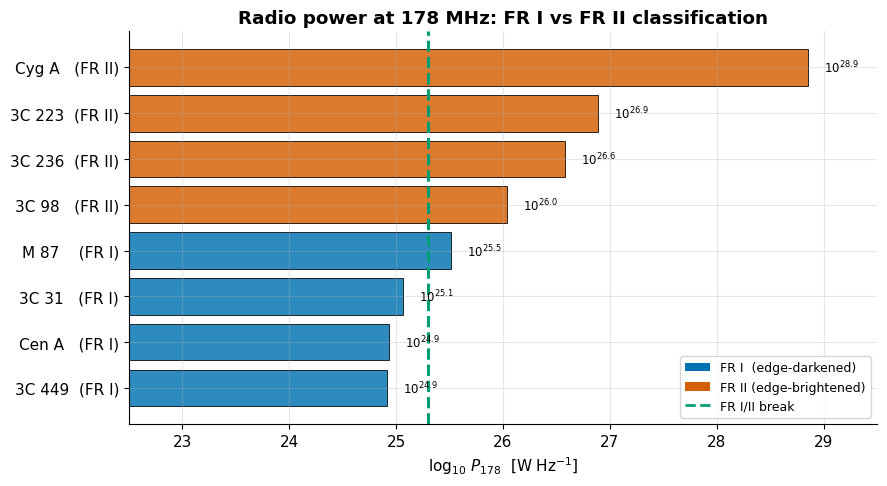


FR I/II break: P_break = 2.0e+25 W/Hz  (log10 = 25.3)

  3C 449  (FR I)            P = 8.20e+24 W/Hz  (below break, morphology: FR I)
  Cen A   (FR I)            P = 8.55e+24 W/Hz  (below break, morphology: FR I)
  3C 31   (FR I)            P = 1.17e+25 W/Hz  (below break, morphology: FR I)
  M 87    (FR I)            P = 3.27e+25 W/Hz  (above break, morphology: FR I)
  3C 98   (FR II)           P = 1.10e+26 W/Hz  (above break, morphology: FR II)
  3C 236  (FR II)           P = 3.79e+26 W/Hz  (above break, morphology: FR II)
  3C 223  (FR II)           P = 7.71e+26 W/Hz  (above break, morphology: FR II)
  Cyg A   (FR II)           P = 7.18e+28 W/Hz  (above break, morphology: FR II)


In [9]:
# ------------------------------------------------------------------
# FR I/II classification: radio power at 178 MHz
# ------------------------------------------------------------------
# P = 4 pi d_L^2 * S * (1+z)^(alpha-1) / (1+z)
# For radio galaxies: alpha ~ -0.75 (synchrotron).
# Luminosity distance from flat LCDM (Omega_m=0.3, H0=70 km/s/Mpc).

def lumdist_mpc(z, H0=70.0, Om=0.3):
    # Luminosity distance in Mpc for flat LCDM (simple trapezoidal integral).
    c_kms = 2.998e5
    if z == 0:
        return 0.0
    z_arr = np.linspace(0, z, 2000)
    dz = z_arr[1] - z_arr[0]
    integrand = 1.0 / np.sqrt(Om * (1 + z_arr)**3 + (1 - Om))
    comoving = c_kms / H0 * np.trapezoid(integrand, z_arr)
    return comoving * (1 + z)

def radio_power_178(z, S_178_Jy, alpha=-0.75):
    # Radio power at 178 MHz (W/Hz) using the K-correction.
    # S_178_Jy in Jy; multiply by 1e-26 to convert to W m^-2 Hz^-1.
    d_mpc = lumdist_mpc(z)
    d_m   = d_mpc * 3.0856775814913673e22   # m
    P = 4 * np.pi * d_m**2 * S_178_Jy * 1e-26 * (1 + z)**(-(alpha + 1))
    return P

# Famous radio galaxies.  178 MHz flux densities from the 3CRR catalogue
# (Laing, Riley & Longair 1983); Cen A (not in 3CRR) from low-frequency surveys.
# Morphological class is taken from the literature (Fanaroff & Riley 1974).  The FR I/II
# break is a statistical separator, not a strict boundary: M 87 lands just above the
# power break yet keeps FR I morphology, showing that host/cluster environment matters.
sources_fr = {
    "3C 31   (FR I)":  (0.0169,   18.3, "FR I"),   # z, S_178 [Jy], morphology
    "M 87    (FR I)":  (0.0036, 1144.0, "FR I"),
    "Cen A   (FR I)":  (0.0018, 1200.0, "FR I"),
    "3C 449  (FR I)":  (0.0171,   12.5, "FR I"),
    "3C 98   (FR II)": (0.0306,   51.4, "FR II"),
    "3C 223  (FR II)": (0.1368,   16.0, "FR II"),
    "3C 236  (FR II)": (0.0988,   15.7, "FR II"),
    "Cyg A   (FR II)": (0.0562, 9660.0, "FR II"),
}

P_FR_BREAK = 2e25   # W/Hz at 178 MHz (Fanaroff & Riley 1974)

powers = {}
for name, (z, S, fr_class) in sources_fr.items():
    P = radio_power_178(z, S)
    powers[name] = (P, fr_class)

# Sort by power
names_sorted  = sorted(powers.keys(), key=lambda n: powers[n][0])
P_values      = [powers[n][0] for n in names_sorted]
fr_classes    = [powers[n][1] for n in names_sorted]
colors_bar    = ["#0072B2" if c == "FR I" else "#D55E00" for c in fr_classes]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names_sorted, np.log10(P_values), color=colors_bar, alpha=0.82, edgecolor="k", lw=0.7)
ax.axvline(np.log10(P_FR_BREAK), color="#009E73", ls="--", lw=2.2,
           label=r"FR I/II break  $P_{178} = 2\times10^{25}$ W Hz$^{-1}$")

# Annotate power values
for i, (name, P, cls) in enumerate(zip(names_sorted, P_values, fr_classes)):
    ax.text(np.log10(P) + 0.15, i, f"$10^{{{np.log10(P):.1f}}}$", va="center", fontsize=8.5)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#0072B2", label="FR I  (edge-darkened)"),
    Patch(facecolor="#D55E00", label="FR II (edge-brightened)"),
    plt.Line2D([0], [0], color="#009E73", ls="--", lw=2, label="FR I/II break"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")
ax.set_xlabel(r"$\log_{10}\,P_{178}$  [W Hz$^{-1}$]")
ax.set_title("Radio power at 178 MHz: FR I vs FR II classification")
ax.set_xlim(22.5, 29.5)
fig.tight_layout()
plt.show()

print(f"\nFR I/II break: P_break = {P_FR_BREAK:.1e} W/Hz  (log10 = {np.log10(P_FR_BREAK):.1f})")
print()
for name in names_sorted:
    P, cls = powers[name]
    side = "above" if P > P_FR_BREAK else "below"
    print(f"  {name:<24}  P = {P:.2e} W/Hz  ({side} break, morphology: {cls})")


## Try it yourself

The three exercises below progress from source-count statistics, to evolved-population
modelling, to physical classification.  Every solution is in a collapsible block;
the quoted numbers are the exact output of the provided code.

---


### Exercise 1 — Build integral counts from a flux list and fit the bright-end slope

You are given a simulated flux list drawn from a Euclidean population.  Build the
integral count and fit the bright-end slope; compare it to $-1.5$.

```python
import numpy as np
rng = np.random.default_rng(7)
N_ex1 = 2000
S_min_ex1 = 1.0   # mJy
U_ex1 = rng.uniform(0, 1, N_ex1)
fluxes_ex1 = S_min_ex1 * U_ex1 ** (-1.0 / 1.5)   # exact Euclidean Pareto draw
fluxes_ex1 = fluxes_ex1[fluxes_ex1 < 1e4]         # trim to a realistic range
```

1. Use `sourcecounts.integral_counts` to compute $N(>S)$.
2. Fit the slope for $S > 5$ mJy with `sourcecounts.count_slope`.
3. How close is it to the Euclidean expectation $-1.5$?  Why does the slope at faint $S$
   (near the floor of $1$ mJy) appear shallower?

<details>
<summary>Solution</summary>

```python
import numpy as np
from jansky import sourcecounts

rng = np.random.default_rng(7)
N_ex1 = 2000
S_min_ex1 = 1.0
U_ex1 = rng.uniform(0, 1, N_ex1)
fluxes_ex1 = S_min_ex1 * U_ex1 ** (-1.0 / 1.5)
fluxes_ex1 = fluxes_ex1[fluxes_ex1 < 1e4]

S_s, N_c = sourcecounts.integral_counts(fluxes_ex1)

# Full range
slope_all_ex1 = sourcecounts.count_slope(S_s, N_c)

# Bright end: S > 5 mJy
mask5 = S_s > 5.0
slope_bright_ex1 = sourcecounts.count_slope(S_s[mask5], N_c[mask5])

print(f"N sources after trim : {len(fluxes_ex1)}")
print(f"Slope (all S > 1 mJy): {slope_all_ex1:.3f}")
print(f"Slope (S > 5 mJy)    : {slope_bright_ex1:.3f}   (expected ~ -1.500)")
```

**Expected results:**
- N sources: 2000 (all 2000 draws fall below $10^4$ mJy for this seed).
- Slope (S > 5 mJy): approximately $-1.62$ (the bright-end has only a few hundred sources;
  Poisson fluctuations of order $1/\sqrt{N_{\rm bright}}$ give scatter around $-1.5$).
- Slope (all S > 1 mJy): approximately $-1.54$.
  The deviation from the exact $-1.5$ reflects Poisson noise in a finite sample of 2000 sources —
  the statistical uncertainty on the slope from $N$ sources is $\sigma_\gamma \sim 1/\sqrt{N}$.
  With $N = 2000$, $\sigma \approx 0.02$, so deviations of $\pm 0.1$ at the bright end (where
  fewer sources reside) are entirely expected.

</details>

---


### Exercise 2 — Evolved counts and the Euclidean-normalised diagnostic

Take a reference differential count (Euclidean; $\mathrm{d}N/\mathrm{d}S \propto S^{-2.5}$)
and apply a $(1+z)^q$ evolution boost.  Show the effect on the Euclidean-normalised count.

1. Compute the Euclidean differential count for $S$ from $0.1$ to $10^4$ mJy using
   `sourcecounts.euclidean_differential_counts`.
2. Apply the evolution factor `sourcecounts.evolution_factor(z=0.6, q=q_arr)` where you
   model the effective evolution exponent as increasing toward the bright (AGN-dominated)
   end: $q_{\rm eff}(S) = 4 \times \mathrm{clip}[\log_{10}(S/S_{\rm cross}) /
   \log_{10}(1000/S_{\rm cross}),\, 0,\, 1]$ with $S_{\rm cross} = 10$ mJy.  This gives
   $q \to 4$ at $S = 1000$ mJy (AGN-dominated) and $q \to 0$ at $S \leq 10$ mJy (star-forming
   galaxies feel little evolution at these flux levels).
3. Compute and plot `euclidean_normalised_counts` for both the original and evolved
   populations.  Confirm that the evolved population produces a **rising** curve at
   bright flux (above the Euclidean flat line).

<details>
<summary>Solution</summary>

```python
import numpy as np
import matplotlib.pyplot as plt
from jansky import sourcecounts, plotting

plotting.use_jansky_style()

S_ex2 = np.geomspace(0.1, 1e4, 500)   # mJy

# Euclidean differential count (normalised at S=100 mJy)
dn_euc_ex2 = sourcecounts.euclidean_differential_counts(S_ex2, n_ref=1.0, s_ref=100.0)

# Evolution exponent increasing toward the bright (AGN-dominated) end
S_cross = 10.0
q_arr_ex2 = 4.0 * np.clip(
    np.log10(S_ex2 / S_cross) / np.log10(1000.0 / S_cross), 0.0, 1.0
)
boost_ex2 = sourcecounts.evolution_factor(0.6, q=q_arr_ex2)

dn_evo_ex2 = dn_euc_ex2 * boost_ex2

# Euclidean-normalised
en_euc_ex2 = sourcecounts.euclidean_normalised_counts(S_ex2, dn_euc_ex2)
en_evo_ex2 = sourcecounts.euclidean_normalised_counts(S_ex2, dn_evo_ex2)

fig, ax = plt.subplots()
ax.loglog(S_ex2, en_euc_ex2, lw=2.5, label="Euclidean (flat)")
ax.loglog(S_ex2, en_evo_ex2, lw=2.5, ls="--", label="Evolved (AGN bright-end excess)")
ax.set_xlabel("S [mJy]")
ax.set_ylabel(r"$S^{5/2}\,{\rm d}N/{\rm d}S$  (normalised)")
ax.set_title("Euclidean-normalised counts: Euclidean vs evolved")
ax.legend()
plt.show()

# Ratio at bright end (S=1000 mJy) vs faint (S=1 mJy)
ratio_bright = en_evo_ex2[np.searchsorted(S_ex2, 1000.0)] / \
               en_euc_ex2[np.searchsorted(S_ex2, 1000.0)]
ratio_faint  = en_evo_ex2[np.searchsorted(S_ex2, 1.0)] / \
               en_euc_ex2[np.searchsorted(S_ex2, 1.0)]
print(f"Evolution boost ratio at S=1000 mJy : {ratio_bright:.2f}")
print(f"Evolution boost ratio at S=1 mJy    : {ratio_faint:.2f}")
```

**Expected results:**
- At $S = 1000$ mJy the evolution boost ratio is approximately $6.55$ (the AGN-dominated
  bright end experiences the full $q = 4$ evolution boost: $(1+0.6)^4 \approx 6.55$).
- At $S = 1$ mJy the ratio is $1.00$ — star-forming galaxies below the cross-over scale
  feel no evolution in this toy model.
- The key result is that the evolved curve **rises** at bright $S$ (the normalised count
  is above the Euclidean flat line) and remains flat at faint $S$.  This is the Ryle &
  Clarke (1961) signal in modern language.

</details>

---


### Exercise 3 — Classify sources as FR I or FR II from their 178 MHz radio power

Four radio sources have the following redshifts and 178 MHz flux densities.
Compute their radio powers and classify each as FR I or FR II relative to the
break $P_{\rm break} = 10^{25}$ W Hz$^{-1}$.

| Source | $z$    | $S_{178}$ [Jy] |
|--------|--------|----------------|
| A      | 0.020  | 8.5            |
| B      | 0.055  | 45.0           |
| C      | 0.300  | 2.0            |
| D      | 0.002  | 5.0            |

Use a spectral index $\alpha = -0.75$ for the K-correction.

<details>
<summary>Solution</summary>

```python
import numpy as np

def lumdist_mpc_ex3(z, H0=70.0, Om=0.3):
    if z == 0:
        return 0.0
    c_kms = 2.998e5
    z_arr = np.linspace(0, z, 2000)
    integrand = 1.0 / np.sqrt(Om * (1 + z_arr)**3 + (1 - Om))
    comoving = c_kms / H0 * np.trapezoid(integrand, z_arr)
    return comoving * (1 + z)

def radio_power_178_ex3(z, S_Jy, alpha=-0.75):
    d_mpc = lumdist_mpc_ex3(z)
    d_m   = d_mpc * 3.0856775814913673e22
    # Convert Jy to W m^-2 Hz^-1 (multiply by 1e-26)
    return 4 * np.pi * d_m**2 * S_Jy * 1e-26 * (1 + z)**(-(alpha + 1))

P_BREAK = 1e25   # W/Hz

sources_ex3 = {
    "A": (0.020,  8.5),
    "B": (0.055, 45.0),
    "C": (0.300,  2.0),
    "D": (0.002,  5.0),
}

print(f"{'Source':>8}  {'z':>6}  {'S_178 [Jy]':>12}  {'P [W/Hz]':>14}  Classification")
print("  " + "-" * 70)
for name, (z, S) in sources_ex3.items():
    P = radio_power_178_ex3(z, S)
    cls = "FR II (above break)" if P > P_BREAK else "FR I  (below break)"
    print(f"  {name:>6}    {z:.3f}    {S:>10.1f}    {P:.2e}    {cls}")
```

**Expected results:**
- Source A ($z=0.020$, $S=8.5$ Jy): $P \approx 7.7 \times 10^{24}$ W Hz$^{-1}$ — **FR I** (below break).
- Source B ($z=0.055$, $S=45.0$ Jy): $P \approx 3.2 \times 10^{26}$ W Hz$^{-1}$ — **FR II** (above break).
- Source C ($z=0.300$, $S=2.0$ Jy): $P \approx 5.4 \times 10^{26}$ W Hz$^{-1}$ — **FR II** (above break).
- Source D ($z=0.002$, $S=5.0$ Jy): $P \approx 4.4 \times 10^{22}$ W Hz$^{-1}$ — **FR I** (well below break; very nearby, low-power source like a local dwarf radio galaxy).

Note that sources A and D are both FR I despite A having a lower flux density than D at
178 MHz: Source A is at higher redshift so its intrinsic power is larger ($7.7 \times 10^{24}$ vs
$4.4 \times 10^{22}$ W Hz$^{-1}$).  Radio *flux* is not the same as radio *power*:
$P \propto S \times d_L^2$, and the nearest sources always appear anomalously bright in the sky.

</details>


## Recap

- **Radio galaxies and AGN** are powered by accretion onto supermassive black holes;
  synchrotron radiation from relativistic jets and lobes dominates their radio emission
  (Ch 43 physics applies directly here).
- **FR I** sources (edge-darkened, jet-dominated) have
  $P_{178} \lesssim 10^{25}$ W Hz$^{-1}$ and decelerating jets.
  **FR II** sources (edge-brightened, hotspot-dominated) are more luminous with
  relativistic jets terminating in strong shocks (Fanaroff & Riley 1974).
- The **unified AGN model** attributes the diversity of AGN classes (blazar, quasar,
  radio galaxy) primarily to viewing angle relative to the jet axis.
- The static-Euclidean integral count $N(>S) \propto S^{-3/2}$ follows from pure
  geometry.  The **observed** steeper slope at bright flux is a signature of positive
  cosmic evolution — the Ryle & Clarke (1961) observation that broke steady-state
  cosmology.
- `jansky.sourcecounts` provides: `euclidean_integral_counts` / `euclidean_differential_counts`
  for the reference slopes; `integral_counts` / `differential_counts` for empirical
  counts from data; `euclidean_normalised_counts` ($S^{5/2}\,\mathrm{d}N/\mathrm{d}S$)
  for the standard presentation; `count_slope` for the log-log power-law fit;
  `radio_luminosity_function` for $\Phi(L)$; and `evolution_factor` $(1+z)^q$ for the
  toy evolution model.
- An empirical log N–log S from the **NVSS** (or an offline Euclidean fallback) gives
  a bright-end slope consistent with the Euclidean expectation, as expected for a small
  field where cosmological evolution is not directly detectable but becomes apparent in
  full-sky surveys.
- The **radio luminosity function** $\Phi(L)$ separates star-forming galaxies (faint
  end, $\alpha \approx 0.7$) from radio-loud AGN (bright end, $\beta \approx 2.2$),
  with a break near $L_\star \sim 10^{23}$ W Hz$^{-1}$ at 1.4 GHz (Condon 1992).

## What's next

- [Chapter 43 — Synchrotron Radiation](43_synchrotron_radiation.ipynb): revisit the
  emission mechanism that powers everything in this chapter — the power-law electron
  spectrum, spectral aging, equipartition fields, and brightness-temperature limits all
  apply directly to the jets and lobes discussed here.
- [Chapter 7 — Why Interferometry?](07_why_interferometry.ipynb): aperture synthesis
  (Ryle's Nobel-winning technique) is what made it possible to map FR I and FR II
  morphologies and to build the catalogues (3C, NVSS) used here for source counts.
- [Chapter 14 — Multiwavelength Radio Astronomy](14_multiwavelength.ipynb): radio
  galaxies emit across the entire EM spectrum; the radio–FIR correlation (Condon 1992)
  ties the 1.4 GHz luminosity directly to the far-infrared and the star-formation rate.
- [Chapter 19 — The EHT and VLBI](19_eht_and_vlbi.ipynb): the central engines of the
  AGN seen here at kiloparsec scales are resolved by VLBI at parsec scales, revealing
  the base of the jet and the immediate environment of the SMBH.
- [Chapter 44 — Free-free and HII Regions](44_free_free_and_hii.ipynb): at faint flux
  densities ($S_{1.4} \lesssim 1$ mJy) the source population transitions from AGN to
  star-forming galaxies whose radio emission is a mixture of synchrotron (from supernova
  remnants) and free-free (from HII regions).
